# 01b — Websach Inspection

> **Nguồn:** `clean_laptop_features.csv` — catalog laptop mới từ websosanh.vn (đã pre-cleaned, giữ lại 15 cột cần thiết).
>
> **Mục tiêu:** EDA và chuẩn bị merge với Chotot (có fields: `url, price, title, Hãng, Dòng máy, Tình trạng, Chính sách bảo hành, Kích cỡ màn hình, Bộ vi xử lý, RAM, Card màn hình, Ổ cứng, Xuất xứ, Loại ổ cứng`).

**Schema hiện tại (15 cột):**
```
Identity : Hãng sản xuất
CPU      : Công nghệ CPU, Loại CPU
RAM      : Dung lượng RAM, Loại RAM
Storage  : Loại ổ cứng, Dung lượng ổ cứng (GB)
GPU      : Đồ họa đã làm sạch
Display  : Kích thước (inch)
Price    : shop_1_price, shop_1_name, shop_2_price, shop_2_name, shop_3_price, shop_3_name
```

## Table of Contents
1. [Setup & Load](#1-setup--load)
2. [Snapshot & Missing Overview](#2-snapshot--missing-overview)
3. [Nhóm Price — Inspect → Clean → Median](#3-nhóm-price)
   - 3.1–3.6 Price cleaning pipeline
   - 3.7 Price Distribution theo Brand
4. [Nhóm Identity & Display](#4-nhóm-identity--display)
   - 4.3 Brand × Screen Size Heatmap
5. [Nhóm CPU & RAM](#5-nhóm-cpu--ram)
   - 5.4 Price theo CPU Brand & RAM Tier
6. [Nhóm Storage & GPU](#6-nhóm-storage--gpu)
   - 6.4 Storage Capacity × Type & Price Impact
7. [Duplicate Check](#7-duplicate-check)
   - 7b. Correlation — Numeric Specs vs Price
8. [Cross-Source Alignment Plan](#8-cross-source-alignment-plan)
9. [Issues Summary & Cleaning Checklist](#9-issues-summary--cleaning-checklist))

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Helpers ──────────────────────────────────────────────────────────────────
def val_counts_pct(series, n=15):
    vc  = series.value_counts(dropna=False).head(n)
    pct = (vc / len(series) * 100).round(1)
    return pd.DataFrame({'count': vc, '%': pct})

def missing_summary(df):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    return pd.DataFrame({'missing': miss, '%': pct}).query('missing > 0').sort_values('%', ascending=False)

In [2]:
PATH = r"../../data/raw/clean_laptop_features.csv"
df   = pd.read_csv(PATH)

PRICE_COLS = ['shop_1_price', 'shop_2_price', 'shop_3_price']
NAME_COLS  = ['shop_1_name',  'shop_2_name',  'shop_3_name']
SPEC_COLS  = ['Hãng sản xuất', 'Công nghệ CPU', 'Loại CPU',
              'Dung lượng RAM', 'Loại RAM',
              'Loại ổ cứng', 'Dung lượng ổ cứng (GB)',
              'Đồ họa đã làm sạch', 'Kích thước (inch)']

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 4,384 rows × 15 columns


,Hãng sản xuất,Công nghệ CPU,Loại CPU,Dung lượng RAM,Loại RAM,Loại ổ cứng,Dung lượng ổ cứng (GB),Đồ họa đã làm sạch,Kích thước (inch),shop_1_price,shop_1_name,shop_2_price,shop_2_name,shop_3_price,shop_3_name
0,Acer,Intel Core i5,8265U,8.00,DDR4,SSD,512.00,Intel UHD Graphics,14.00,14950000,baochau.vn,15950000,quangmai.net,"15,990,000.00",compro.com.vn
1,Lg,Intel Core i7,1165G7,16.00,LPDDR4x,SSD,512.00,Intel Iris Xe,17.00,32640000,tiki.vn,47500000,tinhocsangtao.vn,"35,190,000.00",mixicomputer.vn
2,Lenovo,AMD Ryzen 7,8845HS,16.00,DDR5,SSD,512.00,RTX 4060,16.00,30900000,congnghesgsaigon.com,31490000,tnc.com.vn,"33,490,000.00",tymo.vn


In [3]:
# ── Parse giá → triệu VND ───────────────────────────────────────────────────
# FIX: Chỉ parse 1 lần tại đây. Section 3 KHÔNG parse lại.
#      Sau hàm này, PRICE_COLS đã ở đơn vị triệu VND (float).

def clean_price_to_million_vnd(x):
    """
    Nhận vào giá dạng string hoặc số (VND hoặc đã là triệu VND),
    trả về float theo đơn vị triệu VND. Trả về np.nan nếu không parse được.

    Xử lý các dạng:
      - 15,990,000   → 15.99
      - 15.990.000   → 15.99
      - 15,990,000.00 → 15.99
      - 15.99        → 15.99 (đã là triệu, không đổi)
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    if s == '' or s.lower() in ['nan', 'none', 'null']:
        return np.nan

    # Bỏ ký tự không phải số, dấu chấm, dấu phẩy
    s = re.sub(r'[^\d.,]', '', s)
    if s == '':
        return np.nan

    # Dạng: 15,990,000.00  (dấu . là decimal, dấu , là thousands)
    if ',' in s and '.' in s:
        if s.rfind('.') > s.rfind(','):
            s = s.replace(',', '')
        else:
            s = s.replace('.', '').replace(',', '.')

    # Dạng: 15,990,000  hoặc  15,99  (decimal dùng dấu ,)
    elif ',' in s:
        parts = s.split(',')
        if len(parts) > 2 or len(parts[-1]) == 3:
            s = s.replace(',', '')   # thousands separator
        else:
            s = s.replace(',', '.')  # decimal separator

    # Dạng: 15.990.000  hoặc  15990000.00
    elif '.' in s:
        parts = s.split('.')
        if len(parts) > 2 or len(parts[-1]) == 3:
            s = s.replace('.', '')   # thousands separator

    try:
        price_vnd = float(s)
    except ValueError:
        return np.nan

    # Nếu giá < 1000 → đã là triệu VND rồi (giả định min ~3M)
    # Nếu giá >= 1000 → vẫn là VND đầy đủ → chia 1_000_000
    return price_vnd if price_vnd < 1_000 else price_vnd / 1_000_000


for col in PRICE_COLS:
    df[col] = df[col].apply(clean_price_to_million_vnd)

print("Sau parse — đơn vị: triệu VND")
df[PRICE_COLS].describe().round(2)

Sau parse — đơn vị: triệu VND


,shop_1_price,shop_2_price,shop_3_price
count,"4,384.00","4,384.00","4,382.00"
mean,25.58,25.96,27.78
std,21.55,17.40,51.09
min,3.40,3.00,3.50
25%,14.59,15.09,15.50
50%,20.69,21.25,21.70
75%,30.91,31.00,31.49
max,860.00,179.40,"2,750.00"


---
## 2. Snapshot & Missing Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hãng sản xuất           4204 non-null   object 
 1   Công nghệ CPU           4290 non-null   object 
 2   Loại CPU                4315 non-null   object 
 3   Dung lượng RAM          4363 non-null   float64
 4   Loại RAM                4066 non-null   object 
 5   Loại ổ cứng             4165 non-null   object 
 6   Dung lượng ổ cứng (GB)  4159 non-null   float64
 7   Đồ họa đã làm sạch      4384 non-null   object 
 8   Kích thước (inch)       4373 non-null   float64
 9   shop_1_price            4384 non-null   float64
 10  shop_1_name             4384 non-null   object 
 11  shop_2_price            4384 non-null   float64
 12  shop_2_name             4384 non-null   object 
 13  shop_3_price            4382 non-null   float64
 14  shop_3_name             4382 non-null   

,missing,%
Loại RAM,318,7.30
Dung lượng ổ cứng (GB),225,5.10
Loại ổ cứng,219,5.00
Hãng sản xuất,180,4.10
Công nghệ CPU,94,2.10
Loại CPU,69,1.60
Dung lượng RAM,21,0.50
Kích thước (inch),11,0.30
shop_3_price,2,0.00
shop_3_name,2,0.00


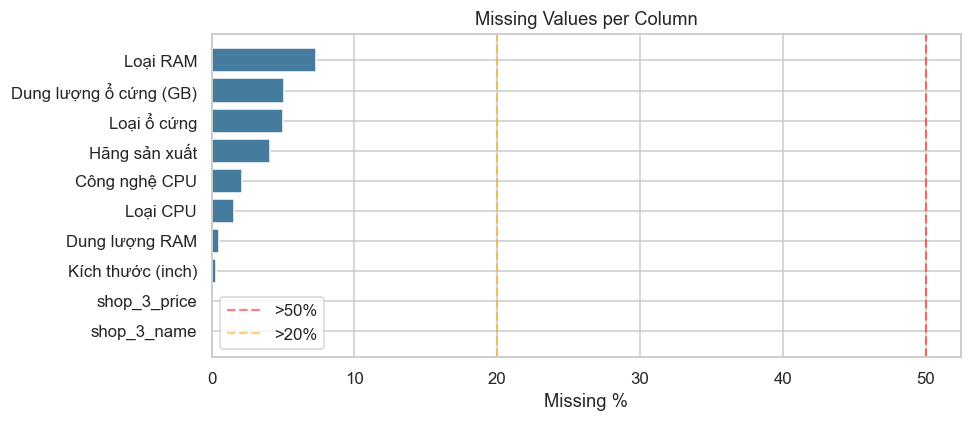

In [5]:
miss = missing_summary(df)

if miss.empty:
    print("Không có missing values.")
else:
    display(miss)
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#e63946' if v > 50 else '#f4a261' if v > 20 else '#457b9d'
              for v in miss['%']]
    ax.barh(miss.index[::-1], miss['%'][::-1], color=colors[::-1])
    ax.axvline(50, color='red',    linestyle='--', alpha=0.5, label='>50%')
    ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='>20%')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values per Column')
    ax.legend()
    plt.tight_layout()
    plt.show()


---
## 3. Nhóm Price

**Workflow:**
1. Inspect distribution per shop (data đã parse sang triệu VND ở Setup)
2. Null-out domain outlier per cell (< 3M hoặc > 200M)
3. Tính variance giữa các shop → **flag rows có spread lớn**
4. Null-out cell lệch > 2× row mean (dùng mean từ bước domain-filter, không tính lại)
5. **Sau khi clean xong** → mới tính `price_median`

> **Lưu ý đơn vị:** Tất cả PRICE_COLS đã là **triệu VND** sau Setup → PRICE_LO = 3, PRICE_HI = 200.

In [6]:
# ── 3.1 Số giá có per row ───────────────────────────────────────────────────
df['n_prices'] = df[PRICE_COLS].notna().sum(axis=1)

print("Số lượng giá có per row:")
display(df['n_prices'].value_counts().sort_index().rename('rows').to_frame())
print(f"\nRows không có bất kỳ giá nào: {(df['n_prices'] == 0).sum()}  ← sẽ drop sau")

Số lượng giá có per row:


,rows
n_prices,
2,2
3,4382



Rows không có bất kỳ giá nào: 0  ← sẽ drop sau


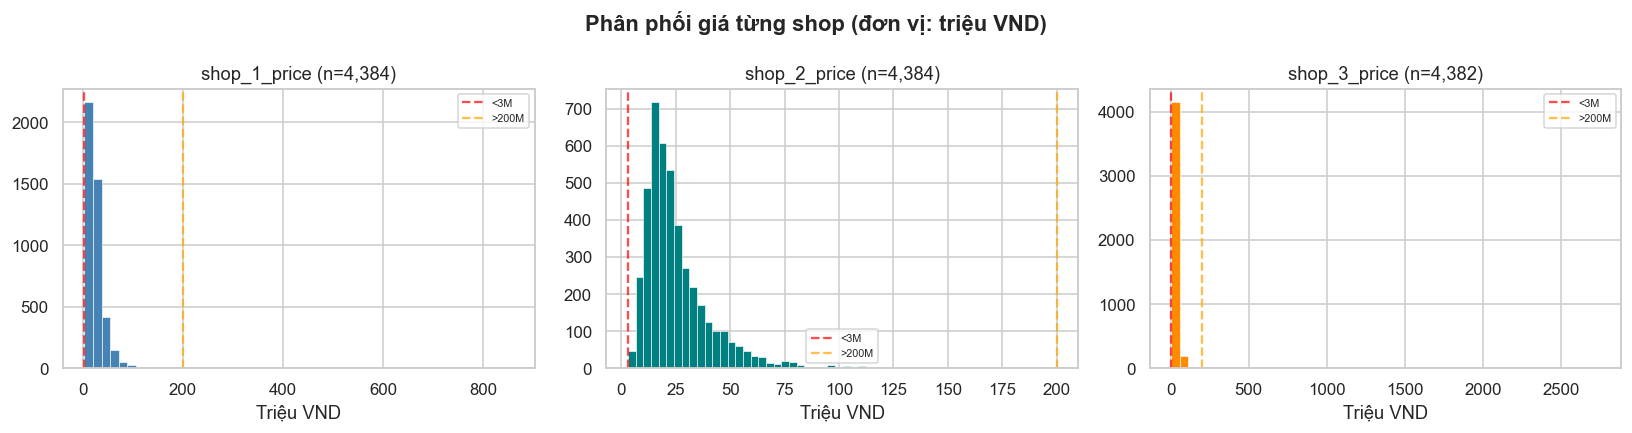

,shop_1_price,shop_2_price,shop_3_price
count,"4,384.00","4,384.00","4,382.00"
mean,25.58,25.96,27.78
std,21.55,17.40,51.09
min,3.40,3.00,3.50
25%,14.59,15.09,15.50
50%,20.69,21.25,21.70
75%,30.91,31.00,31.49
max,860.00,179.40,"2,750.00"


In [7]:
# ── 3.2 Distribution từng shop ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_shop = ['steelblue', 'teal', 'darkorange']

for ax, col, c in zip(axes, PRICE_COLS, colors_shop):
    s    = df[col].dropna()
    n_ok = df[col].notna().sum()          # FIX: count từ df gốc, không phải s.notna()
    ax.hist(s, bins=50, color=c, edgecolor='white', linewidth=0.4)
    ax.set_title(f'{col} (n={n_ok:,})')
    ax.set_xlabel('Triệu VND')
    ax.axvline(3,   color='red',    linestyle='--', alpha=0.7, label='<3M')
    ax.axvline(200, color='orange', linestyle='--', alpha=0.7, label='>200M')
    ax.legend(fontsize=7)

plt.suptitle('Phân phối giá từng shop (đơn vị: triệu VND)', fontweight='bold')
plt.tight_layout()
plt.show()

display(df[PRICE_COLS].describe().round(2))


In [8]:
# ── 3.3 Domain outlier per cell ─────────────────────────────────────────────
# FIX: Threshold đúng đơn vị triệu VND (không phải 3e6 / 200e6)
PRICE_LO, PRICE_HI = 3, 200   # triệu VND

print(f"Outlier per shop (< {PRICE_LO}M hoặc > {PRICE_HI}M triệu VND):")
for col in PRICE_COLS:
    n_lo = (df[col] <  PRICE_LO).sum()
    n_hi = (df[col] >  PRICE_HI).sum()
    print(f"  {col:20s} | <{PRICE_LO}M: {n_lo:4d} | >{PRICE_HI}M: {n_hi:4d}")

# Null-out domain outlier — làm việc trên bản copy để không thay đổi df gốc
df_p = df[PRICE_COLS].copy()
for col in PRICE_COLS:
    df_p.loc[(df_p[col] < PRICE_LO) | (df_p[col] > PRICE_HI), col] = np.nan

Outlier per shop (< 3M hoặc > 200M triệu VND):
  shop_1_price         | <3M:    0 | >200M:    1
  shop_2_price         | <3M:    0 | >200M:    0
  shop_3_price         | <3M:    0 | >200M:    3


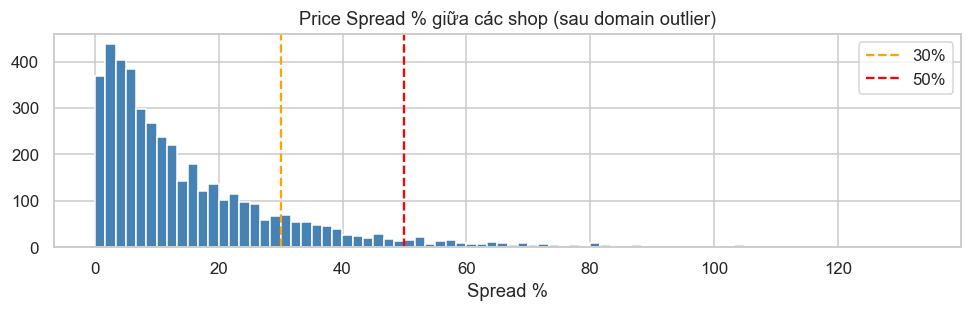

Spread > 50% :  203 rows  ← likely lỗi nhập liệu, cần review
Spread 30–50%:  439 rows  ← nên xem xét


In [9]:
# ── 3.4 Variance check — phát hiện lỗi dữ liệu ─────────────────────────────
row_mean = df_p.mean(axis=1)
row_max  = df_p.max(axis=1)
row_min  = df_p.min(axis=1)

# Chỉ tính spread khi có ít nhất 2 giá hợp lệ
n_valid = df_p.notna().sum(axis=1)
spread  = ((row_max - row_min) / row_mean * 100).where(n_valid >= 2)
df['price_spread_pct'] = spread.round(1)

fig, ax = plt.subplots(figsize=(9, 3))
df['price_spread_pct'].dropna().hist(bins=80, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(30, color='orange', linestyle='--', label='30%')
ax.axvline(50, color='red',    linestyle='--', label='50%')
ax.set_title('Price Spread % giữa các shop (sau domain outlier)')
ax.set_xlabel('Spread %')
ax.legend()
plt.tight_layout()
plt.show()

n_hi  = (df['price_spread_pct'] > 50).sum()
n_med = ((df['price_spread_pct'] > 30) & (df['price_spread_pct'] <= 50)).sum()
print(f"Spread > 50% : {n_hi:4d} rows  ← likely lỗi nhập liệu, cần review")
print(f"Spread 30–50%: {n_med:4d} rows  ← nên xem xét")

In [10]:
# ── 3.5 Review sample rows spread cao ──────────────────────────────────────
high_spread_idx = df['price_spread_pct'] > 50
display(
    df.loc[high_spread_idx, PRICE_COLS + NAME_COLS + ['Hãng sản xuất', 'price_spread_pct']]
    .head(20)
)

# Shop nào hay lệch nhất (dùng row_mean từ bước domain-filter)
print("\nSố lần từng shop bị lệch > 2× row mean:")
for col in PRICE_COLS:
    ratio = (df_p[col] / row_mean)
    n_sus = ((ratio < 0.5) | (ratio > 2.0)).sum()
    print(f"  {col}: {n_sus} rows")

,shop_1_price,shop_2_price,shop_3_price,shop_1_name,shop_2_name,shop_3_name,Hãng sản xuất,price_spread_pct
18,11.49,18.50,9.50,dienmayxanh.com,shopee.vn,vodien.vn,Msi,68.40
20,28.50,38.99,47.90,hungphatlaptop.com,laptoptld.com,vanphatmobile.com,Samsung,50.40
35,13.77,6.50,13.35,cameranhapkhau.com,laptopbinhduongvtc.vn,compro.com.vn,Dell,64.80
94,8.49,17.39,17.89,ttcenter.com.vn,anp.com.vn,compro.com.vn,Dell,64.40
110,6.49,7.59,11.69,maytinhgiare.vn,cityapple.vn,sondat.vn,Asus,60.50
121,21.50,34.00,14.90,hkc.vn,shopee.vn,laptop15.vn,Msi,81.40
187,5.90,14.49,15.25,laptopcudaklak.com,anp.com.vn,compro.com.vn,Hp,78.70
188,23.50,32.00,39.90,laptophitech.vn,zin100.vn,hungphatlaptop.com,Lenovo,51.60
222,14.99,7.59,11.05,tinhocsangtao.vn,maytinhquangmau.vn,mayina0.com,Hp,66.00
231,9.26,4.00,9.45,hkc.vn,laptop36.vn,sondat.vn,Dell,72.00



Số lần từng shop bị lệch > 2× row mean:
  shop_1_price: 9 rows
  shop_2_price: 3 rows
  shop_3_price: 0 rows


In [11]:
# ── 3.6 Null-out cell lệch > 2× → tính price_median ────────────────────────
# FIX: Dùng row_mean từ bước 3.4 (sau domain filter) thay vì tính lại trên df_p_final
#      → tránh circular reference khi outlier tự ảnh hưởng mean của chính nó

df_p_final = df_p.copy()
for col in PRICE_COLS:
    ratio = df_p_final[col] / row_mean          # row_mean từ cell 3.4
    df_p_final.loc[(ratio < 0.5) | (ratio > 2.0), col] = np.nan

df['price_median']   = df_p_final.median(axis=1)
df['n_prices_clean'] = df_p_final.notna().sum(axis=1)

print("Số giá hợp lệ sau clean:")
display(df['n_prices_clean'].value_counts().sort_index().rename('rows').to_frame())
print(f"\nRows null hết sau clean: {df['price_median'].isna().sum()}")
print("\nPrice median — final (triệu VND):")
display(df['price_median'].describe().round(2).to_frame())

Số giá hợp lệ sau clean:


,rows
n_prices_clean,
2,18
3,4366



Rows null hết sau clean: 0

Price median — final (triệu VND):


,price_median
count,"4,384.00"
mean,26.03
std,17.39
min,3.47
25%,15.20
50%,21.19
75%,30.99
max,179.40


### 3.7 Price Distribution theo Brand

> Phát hiện brand nào có price variance cao bất thường — cần stratify khi merge.

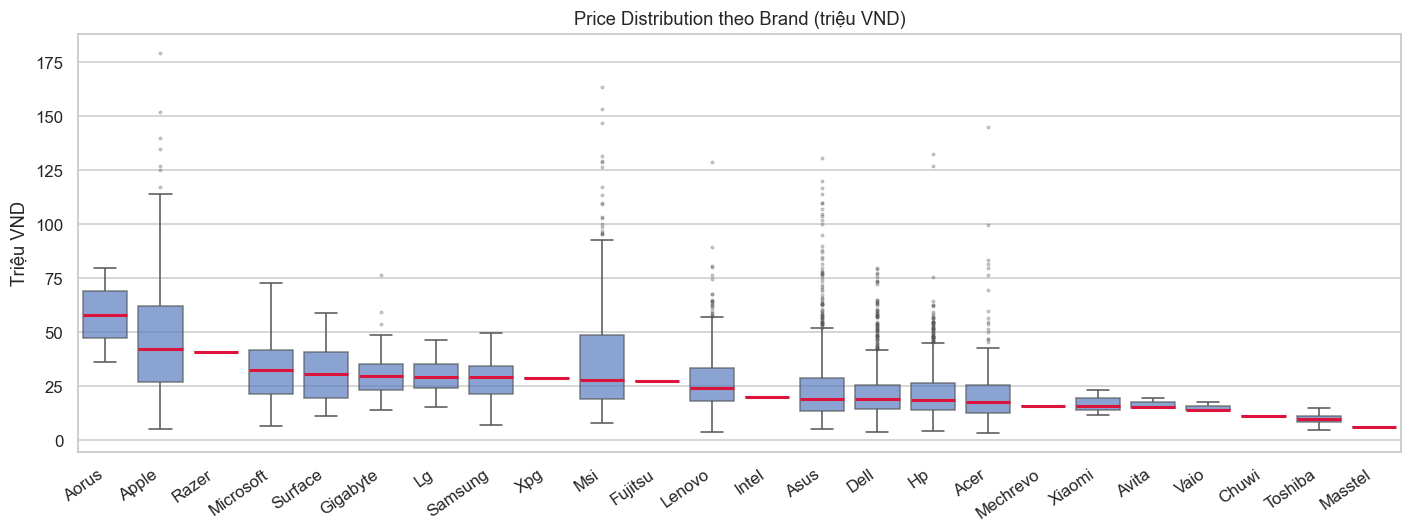

Top 5 brands có IQR giá rộng nhất:


,IQR (triệu VND)
Hãng sản xuất,
Apple,34.80
Msi,29.90
Aorus,21.80
Surface,21.00
Microsoft,20.60


In [12]:
# ── 3.7 Price Distribution theo Brand ───────────────────────────────────────
brand_order = (
    df.groupby('Hãng sản xuất')['price_median']
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=df, x='Hãng sản xuất', y='price_median',
    order=brand_order, ax=ax,
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    medianprops=dict(color='crimson', linewidth=2),
    boxprops=dict(alpha=0.7),
)
ax.set_title('Price Distribution theo Brand (triệu VND)')
ax.set_xlabel('')
ax.set_ylabel('Triệu VND')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# IQR per brand
print("Top 5 brands có IQR giá rộng nhất:")
brand_iqr = (
    df.groupby('Hãng sản xuất')['price_median']
    .agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
    .sort_values(ascending=False).head(5).round(1)
)
display(brand_iqr.rename('IQR (triệu VND)').to_frame())


---
## 4. Nhóm Identity & Display

In [13]:
# ── 4.1 Brand ───────────────────────────────────────────────────────────────
print("Hãng sản xuất:")
display(val_counts_pct(df['Hãng sản xuất']))

# Alias check: case khác nhau cho cùng brand
brands  = df['Hãng sản xuất'].dropna().unique()
suspect = [b for b in brands if b.upper() in [x.upper() for x in brands if x != b]]
if suspect:
    print(f"\nPotential alias (same name, different case): {suspect}")
else:
    print("\nKhông phát hiện alias case-sensitive.")

Hãng sản xuất:


,count,%
Hãng sản xuất,,
Hp,832,19.00
Dell,805,18.40
Lenovo,802,18.30
Asus,801,18.30
Acer,314,7.20
Msi,275,6.30
NaN,180,4.10
Apple,146,3.30
Microsoft,89,2.00



Không phát hiện alias case-sensitive.


In [14]:
# ── 4.2 Screen size ──────────────────────────────────────────────────────────
print("Kích thước (inch) — distribution:")
display(val_counts_pct(
    df['Kích thước (inch)'].astype(str).str.replace(r'\.0$', '', regex=True)
))

n_outlier = (df['Kích thước (inch)'] > 25).sum()
n_missing = df['Kích thước (inch)'].isna().sum()
print(f"\nOutlier > 25 inch: {n_outlier} rows")
print(f"Missing          : {n_missing} rows")

Kích thước (inch) — distribution:


,count,%
Kích thước (inch),,
14,1525,34.80
15.6,1354,30.90
16,553,12.60
13.3,299,6.80
17.3,70,1.60
16.1,64,1.50
14.5,45,1.00
13,44,1.00
13.4,41,0.90



Outlier > 25 inch: 85 rows
Missing          : 11 rows


### 4.3 Brand × Screen Size Heatmap

> Mỗi brand tập trung vào form factor nào — cần cho merge matching logic.

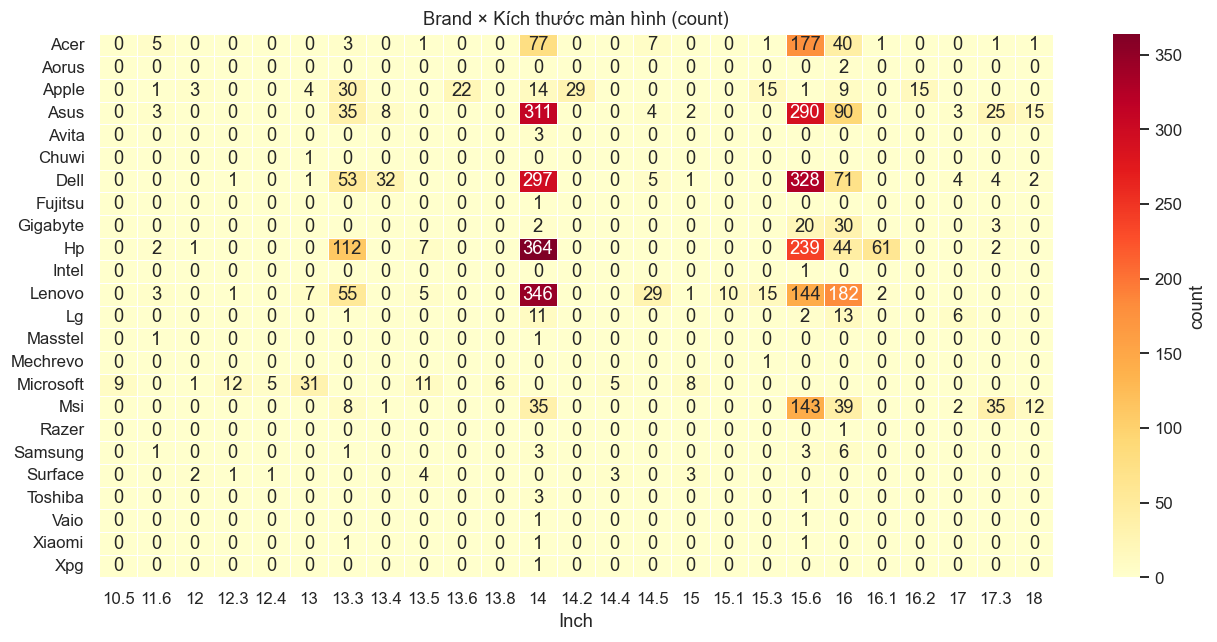

In [15]:
# ── 4.3 Brand × Screen size heatmap ─────────────────────────────────────────
screen_clean = df['Kích thước (inch)'].astype(str).str.replace(r'\.0$', '', regex=True)
brand_screen = pd.crosstab(df['Hãng sản xuất'], screen_clean)

common_screens = brand_screen.columns[brand_screen.sum() >= 5]
brand_screen   = brand_screen[common_screens]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(brand_screen, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'count'})
ax.set_title('Brand × Kích thước màn hình (count)')
ax.set_xlabel('Inch')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


---
## 5. Nhóm CPU & RAM

In [16]:
# ── 5.1 CPU brand ────────────────────────────────────────────────────────────
df['cpu_brand'] = np.select(
    [
        df['Công nghệ CPU'].str.contains('Intel',    case=False, na=False),
        df['Công nghệ CPU'].str.contains('AMD',      case=False, na=False),
        df['Công nghệ CPU'].str.contains('Apple',    case=False, na=False),
        df['Công nghệ CPU'].str.contains('Qualcomm', case=False, na=False),
    ],
    ['Intel', 'AMD', 'Apple', 'Qualcomm'],
    default='Unknown'
)
print("CPU Brand:")
display(val_counts_pct(df['cpu_brand']))

# Inspect 'Unknown' để xác nhận có cần thêm brand không
n_unk = (df['cpu_brand'] == 'Unknown').sum()
if n_unk > 0:
    print(f"\nUnknown CPU ({n_unk} rows) — sample 'Công nghệ CPU':")
    display(val_counts_pct(df.loc[df['cpu_brand'] == 'Unknown', 'Công nghệ CPU']).head(10))

print("\nTop CPU models (Loại CPU):")
display(val_counts_pct(df['Loại CPU']))


CPU Brand:


,count,%
cpu_brand,,
Intel,3488,79.60
AMD,555,12.70
Unknown,213,4.90
Apple,127,2.90
Qualcomm,1,0.00



Unknown CPU (213 rows) — sample 'Công nghệ CPU':


,count,%
Công nghệ CPU,,
NaN,94,44.10
Ultra 7,27,12.70
Ultra 5,21,9.90
Snapdragon X Elite,16,7.50
Snapdragon X Plus,11,5.20
Snapdragon X,6,2.80
Ultra 9,6,2.80
Ryzen 5,6,2.80
Ryzen 7,4,1.90



Top CPU models (Loại CPU):


,count,%
Loại CPU,,
1135G7,235,5.40
1235U,129,2.90
1355U,103,2.30
1165G7,101,2.30
155H,99,2.30
8265U,97,2.20
1335U,96,2.20
8250U,90,2.10
1115G4,80,1.80


In [17]:
# ── 5.2 RAM ──────────────────────────────────────────────────────────────────
print("Dung lượng RAM (GB):")
display(val_counts_pct(
    df['Dung lượng RAM'].astype(str).str.replace(r'\.0$', '', regex=True)
))

print("\nLoại RAM:")
display(val_counts_pct(df['Loại RAM']))

Dung lượng RAM (GB):


,count,%
Dung lượng RAM,,
16,1648,37.60
8,1448,33.00
4,595,13.60
32,507,11.60
24,58,1.30
64,52,1.20
nan,21,0.50
128,12,0.30
36,9,0.20



Loại RAM:


,count,%
Loại RAM,,
DDR4,2112,48.20
DDR5,1119,25.50
NaN,318,7.30
LPDDR5x,251,5.70
LPDDR5,241,5.50
LPDDR4x,87,2.00
DDR3L,62,1.40
DDR3,60,1.40
LPDDR3,43,1.00


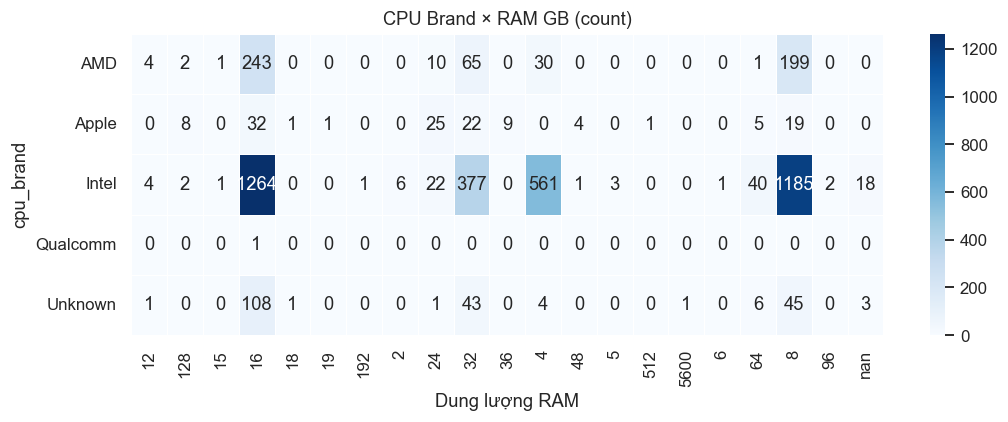

In [18]:
# ── 5.3 CPU × RAM heatmap (count) ────────────────────────────────────────────
cpu_ram = pd.crosstab(
    df['cpu_brand'],
    df['Dung lượng RAM'].astype(str).str.replace(r'\.0$', '', regex=True)
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cpu_ram, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('CPU Brand × RAM GB (count)')
plt.tight_layout()
plt.show()

### 5.4 Price theo CPU Brand & RAM Tier

> Hai yếu tố ảnh hưởng giá nhất — dùng để validate price_median sau merge.

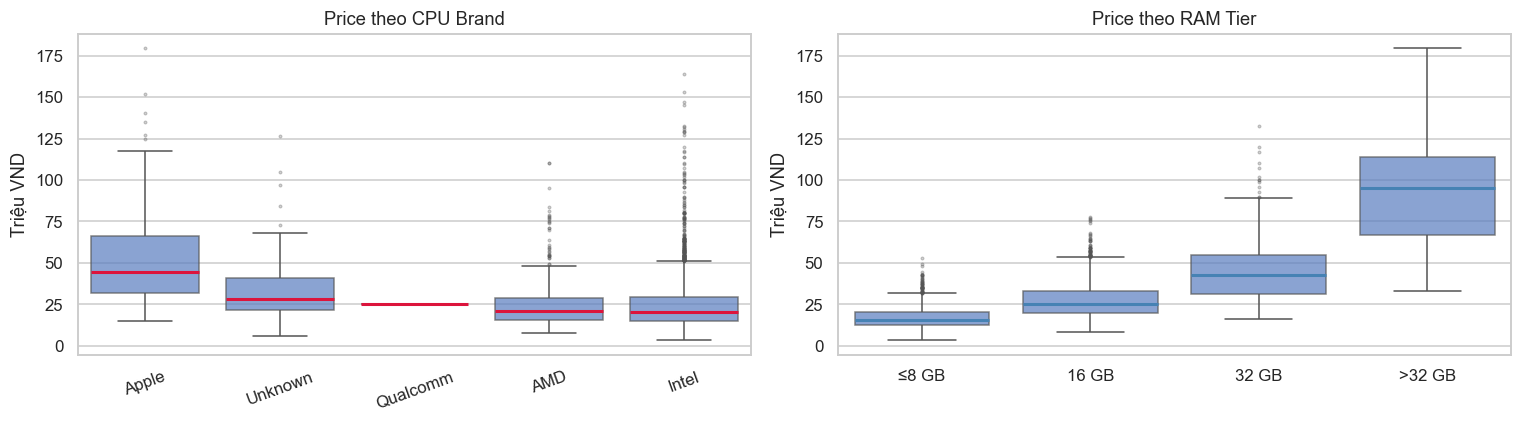

Median price theo CPU brand:


,median_price,n
cpu_brand,,
Apple,44.50,127
Unknown,27.90,213
Qualcomm,24.90,1
AMD,21.00,555
Intel,20.30,3488


In [19]:
# ── 5.4 Price by CPU brand & RAM tier ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# CPU brand
cpu_order = (
    df.groupby('cpu_brand')['price_median'].median()
    .sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df, x='cpu_brand', y='price_median', order=cpu_order,
            ax=axes[0],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='crimson', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[0].set_title('Price theo CPU Brand')
axes[0].set_xlabel('')
axes[0].set_ylabel('Triệu VND')
axes[0].tick_params(axis='x', rotation=20)

# RAM tier
ram_num = pd.to_numeric(df['Dung lượng RAM'], errors='coerce')
df['ram_tier'] = pd.cut(
    ram_num, bins=[0, 8, 16, 32, 999],
    labels=['≤8 GB', '16 GB', '32 GB', '>32 GB']
)
ram_order = ['≤8 GB', '16 GB', '32 GB', '>32 GB']
sns.boxplot(data=df, x='ram_tier', y='price_median', order=ram_order,
            ax=axes[1],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='steelblue', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[1].set_title('Price theo RAM Tier')
axes[1].set_xlabel('')
axes[1].set_ylabel('Triệu VND')

plt.tight_layout()
plt.show()

print("Median price theo CPU brand:")
display(
    df.groupby('cpu_brand')['price_median']
    .agg(['median', 'count']).round(1)
    .sort_values('median', ascending=False)
    .rename(columns={'median': 'median_price', 'count': 'n'})
)


---
## 6. Nhóm Storage & GPU

In [20]:
# ── 6.1 Storage ──────────────────────────────────────────────────────────────
print("Loại ổ cứng:")
display(val_counts_pct(df['Loại ổ cứng']))

print("\nDung lượng ổ cứng (GB):")
display(val_counts_pct(
    df['Dung lượng ổ cứng (GB)'].astype(str).str.replace(r'\.0$', '', regex=True)
))

Loại ổ cứng:


,count,%
Loại ổ cứng,,
SSD,3697,84.30
HDD,402,9.20
NaN,219,5.00
SSD + HDD,30,0.70
HDD + SSD,27,0.60
SSd,4,0.10
256GB,2,0.00
512GB,1,0.00
eMMC,1,0.00



Dung lượng ổ cứng (GB):


,count,%
Dung lượng ổ cứng (GB),,
512,2201,50.20
1024,1036,23.60
256,607,13.80
nan,225,5.10
500,110,2.50
2048,71,1.60
128,51,1.20
1152,36,0.80
4096,12,0.30


In [21]:
# ── 6.2 GPU brand ────────────────────────────────────────────────────────────
# FIX: Bỏ pd.Series() wrapper thừa
df['gpu_brand'] = np.select(
    [
        df['Đồ họa đã làm sạch'].str.contains('RTX|GTX|GeForce|NVIDIA', case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Radeon|RX|AMD',          case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Intel|Iris|UHD',         case=False, na=False),
        df['Đồ họa đã làm sạch'].str.contains('Apple',                  case=False, na=False),
    ],
    ['NVIDIA', 'AMD', 'Intel', 'Apple'],
    default='Unknown'
)
print("GPU Brand:")
display(val_counts_pct(df['gpu_brand']))

print("\nTop GPU models:")
display(val_counts_pct(df['Đồ họa đã làm sạch']))

GPU Brand:


,count,%
gpu_brand,,
Intel,2039,46.50
NVIDIA,1059,24.20
Unknown,812,18.50
AMD,358,8.20
Apple,116,2.60



Top GPU models:


,count,%
Đồ họa đã làm sạch,,
Intel Iris Xe,960,21.90
Intel UHD Graphics,761,17.40
Other GPU,605,13.80
AMD Radeon Graphics,328,7.50
Intel Arc Graphics,318,7.30
Unknown,207,4.70
RTX 3050,195,4.40
RTX 4050,125,2.90
Apple GPU,116,2.60


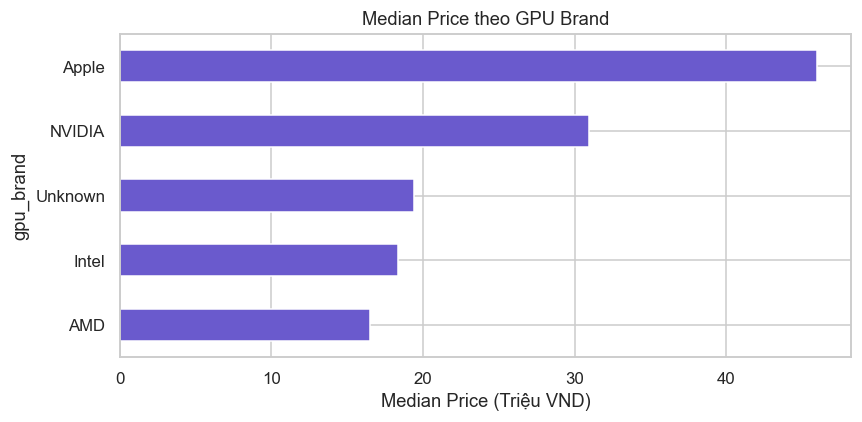

In [22]:
# ── 6.3 Price by GPU brand ───────────────────────────────────────────────────
# FIX: price_median đã là triệu VND → KHÔNG chia 1e6 nữa
fig, ax = plt.subplots(figsize=(8, 4))
gpu_price = df.groupby('gpu_brand')['price_median'].median().sort_values()
gpu_price.plot(kind='barh', ax=ax, color='slateblue')
ax.set_xlabel('Median Price (Triệu VND)')
ax.set_title('Median Price theo GPU Brand')
plt.tight_layout()
plt.show()

### 6.4 Storage Capacity × Type & Price Impact

> SSD vs HDD, dung lượng phổ biến — thông tin cần cho cleaning `Loại ổ cứng` downstream.

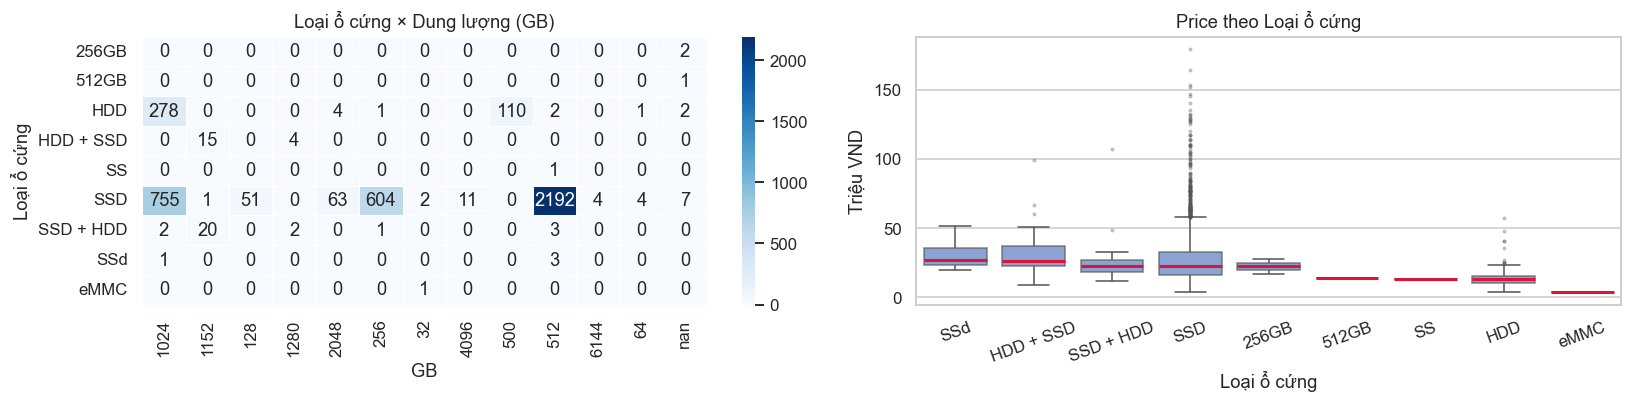

In [23]:
# ── 6.4 Storage type × capacity + price ─────────────────────────────────────
stor_gb_clean = df['Dung lượng ổ cứng (GB)'].astype(str).str.replace(r'\.0$', '', regex=True)
stor_cross    = pd.crosstab(df['Loại ổ cứng'], stor_gb_clean)

common_gb  = stor_cross.columns[stor_cross.sum() >= 3]
stor_cross = stor_cross[common_gb]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.heatmap(stor_cross, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.4)
axes[0].set_title('Loại ổ cứng × Dung lượng (GB)')
axes[0].set_xlabel('GB')

# Price by storage type — sns.boxplot thay df.boxplot
stor_order = (
    df.groupby('Loại ổ cứng')['price_median'].median()
    .sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df, x='Loại ổ cứng', y='price_median', order=stor_order,
            ax=axes[1],
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
            medianprops=dict(color='crimson', linewidth=2),
            boxprops=dict(alpha=0.7))
axes[1].set_title('Price theo Loại ổ cứng')
axes[1].set_ylabel('Triệu VND')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()


---
## 7. Duplicate Check

In [24]:
n_full = df.duplicated().sum()
print(f"Full row duplicates: {n_full}")

# Spec-key duplicate (soft — cùng config ≠ cùng sản phẩm)
spec_key = ['Hãng sản xuất', 'Loại CPU', 'Dung lượng RAM',
            'Dung lượng ổ cứng (GB)', 'Kích thước (inch)']
n_spec = df.duplicated(subset=spec_key).sum()
print(f"Spec-key duplicates: {n_spec}")
print("  → Không tự động drop: cùng config có thể khác màu/phiên bản")

# Preview spec duplicates nếu có
if n_spec > 0:
    dup_mask = df.duplicated(subset=spec_key, keep=False)
    display(
        df.loc[dup_mask, spec_key + ['price_median']]
        .sort_values(spec_key)
        .head(10)
    )

Full row duplicates: 0
Spec-key duplicates: 1704
  → Không tự động drop: cùng config có thể khác màu/phiên bản


,Hãng sản xuất,Loại CPU,Dung lượng RAM,Dung lượng ổ cứng (GB),Kích thước (inch),price_median
316,Acer,1005G1,4.00,256.00,15.60,10.50
2065,Acer,1005G1,4.00,256.00,15.60,7.29
2914,Acer,1005G1,4.00,256.00,15.60,12.70
1231,Acer,10210U,4.00,256.00,15.60,14.57
4295,Acer,10210U,4.00,256.00,15.60,11.89
677,Acer,10210U,8.00,512.00,15.60,16.95
829,Acer,10210U,8.00,512.00,15.60,15.21
574,Acer,10300H,8.00,512.00,15.60,14.49
652,Acer,10300H,8.00,512.00,15.60,19.25
1541,Acer,10300H,8.00,512.00,15.60,23.26


### 7b. Correlation — Numeric Specs vs Price

> Feature nào predict giá tốt nhất → ưu tiên normalize cho merge.

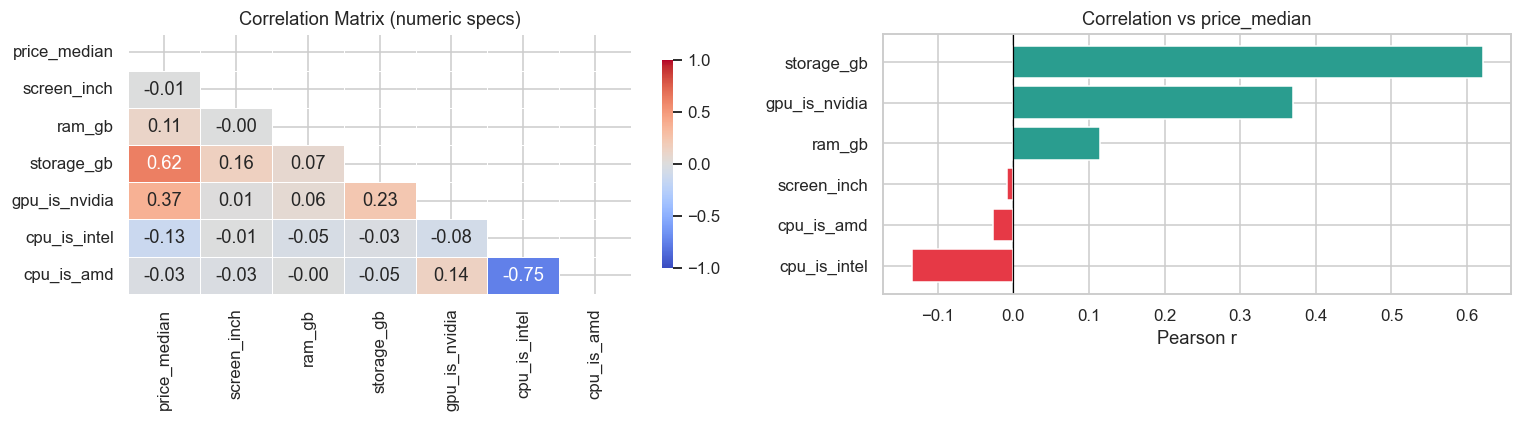

Correlation với price_median (|r| giảm dần):


,|r|
storage_gb,0.62
gpu_is_nvidia,0.37
cpu_is_intel,0.14
ram_gb,0.12
cpu_is_amd,0.03
screen_inch,0.01


In [25]:
# ── 7b Correlation numeric specs vs price_median ─────────────────────────────
num_df = pd.DataFrame({
    'price_median':  df['price_median'],
    'screen_inch':   pd.to_numeric(df['Kích thước (inch)'],       errors='coerce'),
    'ram_gb':        pd.to_numeric(df['Dung lượng RAM'],           errors='coerce'),
    'storage_gb':    pd.to_numeric(df['Dung lượng ổ cứng (GB)'], errors='coerce'),
    'gpu_is_nvidia': (df['gpu_brand'] == 'NVIDIA').astype(int),
    'cpu_is_intel':  (df['cpu_brand'] == 'Intel').astype(int),
    'cpu_is_amd':    (df['cpu_brand'] == 'AMD').astype(int),
})

corr = num_df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix (numeric specs)')

price_corr  = corr['price_median'].drop('price_median').sort_values()
colors_bar  = ['#e63946' if v < 0 else '#2a9d8f' for v in price_corr]
axes[1].barh(price_corr.index, price_corr.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation vs price_median')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print("Correlation với price_median (|r| giảm dần):")
display(price_corr.abs().sort_values(ascending=False).round(3).to_frame('|r|'))


---
## 8. Cross-Source Alignment Plan

Mapping Websach ↔ Source B cho bước merge tại `03_merge.ipynb`.

> **Free-text columns** (`title`, `Thông tin sử dụng` của Source B) **không tham gia schema mapping** — giữ riêng làm dữ liệu bổ sung, không cần align hay chuẩn hoá.

In [26]:
mapping = [
    # target_col       websach                       source_b               transform
    ('price',          'price_median [computed]',    'price',               'numeric, triệu VND'),
    ('brand',          'Hãng sản xuất',              'Hãng',                'title().strip()'),
    ('model_line',     '— NaN',                      'Dòng máy',            'NaN for websach'),
    ('condition',      '— fill Mới',                 'Tình trạng',          'hardcode Mới for websach'),
    ('warranty',       '— NaN',                      'Chính sách bảo hành', 'NaN for websach'),
    ('screen_inch',    'Kích thước (inch)',           'Kích cỡ màn hình',    'extract float'),
    ('cpu_full',       'Công nghệ CPU + Loại CPU',   'Bộ vi xử lý',         'concat & normalize'),
    ('ram_gb',         'Dung lượng RAM',              'RAM',                 'extract int'),
    ('ram_type',       'Loại RAM',                   'RAM [partial]',       'DDR4/5/LPDDR…'),
    ('gpu_model',      'Đồ họa đã làm sạch',         'Card màn hình',       'normalize model name'),
    ('storage_gb',     'Dung lượng ổ cứng (GB)',     'Ổ cứng',              'extract int'),
    ('storage_type',   'Loại ổ cứng',                'Loại ổ cứng',         'SSD/HDD/eMMC upper'),
    ('origin',         '— NaN',                      'Xuất xứ',             'NaN for websach'),
    ('source',         'websach',                    'source_b',            'literal tag'),
]

display(
    pd.DataFrame(mapping, columns=['target_col', 'websach', 'source_b', 'transform'])
    .style.set_properties(**{'text-align': 'left'})
)

print("\nFree-text (không map):")
print("  Source B → title, Thông tin sử dụng : giữ nguyên làm cột bổ sung")
print("  Websach  → không có field tương đương: NaN sau merge")

,target_col,websach,source_b,transform
0,price,price_median [computed],price,"numeric, triệu VND"
1,brand,Hãng sản xuất,Hãng,title().strip()
2,model_line,— NaN,Dòng máy,NaN for websach
3,condition,— fill Mới,Tình trạng,hardcode Mới for websach
4,warranty,— NaN,Chính sách bảo hành,NaN for websach
5,screen_inch,Kích thước (inch),Kích cỡ màn hình,extract float
6,cpu_full,Công nghệ CPU + Loại CPU,Bộ vi xử lý,concat & normalize
7,ram_gb,Dung lượng RAM,RAM,extract int
8,ram_type,Loại RAM,RAM [partial],DDR4/5/LPDDR…
9,gpu_model,Đồ họa đã làm sạch,Card màn hình,normalize model name



Free-text (không map):
  Source B → title, Thông tin sử dụng : giữ nguyên làm cột bổ sung
  Websach  → không có field tương đương: NaN sau merge


---
## 9. Issues Summary & Cleaning Checklist

Input cho `02b_websach_cleaning.ipynb`.

> Cell này tổng hợp tự động các issues phát hiện ở các section trên.
> Chạy sau khi đã chạy hết notebook.

In [27]:
# ── Issues Summary ───────────────────────────────────────────────────────────
issues_rows = []

# Price issues
n_no_price   = (df['n_prices'] == 0).sum()
n_price_null = df['price_median'].isna().sum()
n_spread_hi  = (df['price_spread_pct'] > 50).sum()
issues_rows += [
    ('price', 'no_price_at_all',     n_no_price,   'Drop rows'),
    ('price', 'null_after_cleaning', n_price_null, 'Drop rows'),
    ('price', 'spread_gt_50pct',     n_spread_hi,  'Manual review or winsorize'),
]

# Missing values — FIX: đổi tên biến tránh shadow `miss` ở cell 7
miss_spec = missing_summary(df[SPEC_COLS])
for col, row in miss_spec.iterrows():
    issues_rows.append((col, 'missing', int(row['missing']), f"{row['%']}% — impute or drop"))

# Screen outlier
n_screen_out = (df['Kích thước (inch)'] > 25).sum()
if n_screen_out:
    issues_rows.append(('Kích thước (inch)', 'outlier_gt_25', n_screen_out, 'Verify or null-out'))

# Spec duplicates
spec_key = ['Hãng sản xuất', 'Loại CPU', 'Dung lượng RAM',
            'Dung lượng ổ cứng (GB)', 'Kích thước (inch)']
n_spec_dup = df.duplicated(subset=spec_key).sum()
if n_spec_dup:
    issues_rows.append(('spec_key', 'soft_duplicate', n_spec_dup, 'Keep — same config ≠ same product'))

# Brand alias
brands  = df['Hãng sản xuất'].dropna().unique()
suspect = [b for b in brands if b.upper() in [x.upper() for x in brands if x != b]]
if suspect:
    issues_rows.append(('Hãng sản xuất', 'case_alias', len(suspect), f"Review: {suspect}"))

# Unknown CPU brand còn lại
n_cpu_unk = (df['cpu_brand'] == 'Unknown').sum()
if n_cpu_unk:
    issues_rows.append(('Công nghệ CPU', 'unknown_brand', n_cpu_unk, 'Verify & add to brand map'))

issues = pd.DataFrame(issues_rows, columns=['column', 'issue_type', 'count', 'action'])
display(issues)
print(f"\nTổng {len(issues)} issues cần xử lý trong 02b_websach_cleaning.ipynb")


,column,issue_type,count,action
0,price,no_price_at_all,0,Drop rows
1,price,null_after_cleaning,0,Drop rows
2,price,spread_gt_50pct,203,Manual review or winsorize
3,Loại RAM,missing,318,7.3% — impute or drop
4,Dung lượng ổ cứng (GB),missing,225,5.1% — impute or drop
5,Loại ổ cứng,missing,219,5.0% — impute or drop
6,Hãng sản xuất,missing,180,4.1% — impute or drop
7,Công nghệ CPU,missing,94,2.1% — impute or drop
8,Loại CPU,missing,69,1.6% — impute or drop
9,Dung lượng RAM,missing,21,0.5% — impute or drop



Tổng 14 issues cần xử lý trong 02b_websach_cleaning.ipynb


In [28]:
# ── Save issues checklist ────────────────────────────────────────────────────
import os
OUT_DIR = '../../docs'
os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(OUT_DIR, 'websach_issues_list.csv')
issues.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved: {out_path}")

Saved: ../../docs\websach_issues_list.csv
